(200, 2)


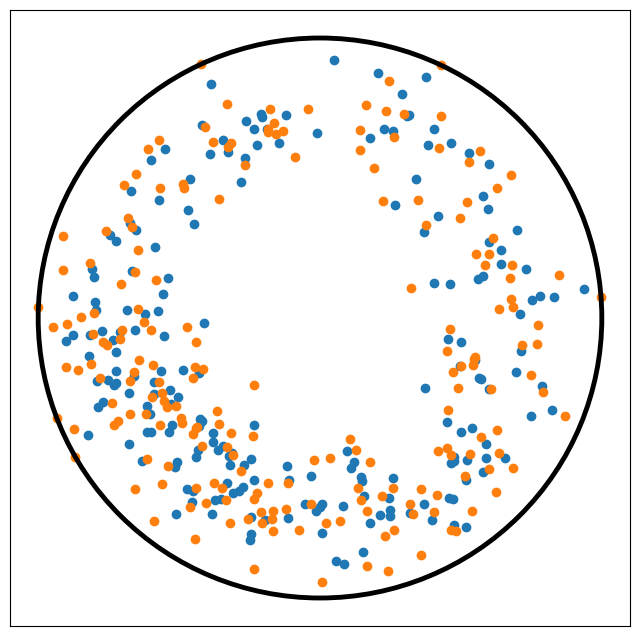

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps

from matplotlib import rcParams

# Disable LaTeX
rcParams["text.usetex"] = False

# Use Garamond or EB Garamond if installed
rcParams["font.family"] = "serif"
rcParams["font.serif"] = ["EB Garamond", "Garamond", "DejaVu Serif"]

pos = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches_1e6_vonMises_beta/vonMises_beta_SM.txt")
print(pos.shape)

def perturb_points_inside_disc(points, R, noise_scale, seed=None, margin=1e-9):

    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, noise_scale, size=points.shape)
    perturbed_points = points + noise

    radii = np.linalg.norm(perturbed_points, axis=1)
    outside_boundary = radii > R
    if np.any(outside_boundary):
        scale = (R - margin) / radii[outside_boundary]
        perturbed_points[outside_boundary] *= scale[:, None]

    return perturbed_points

R = 150.0
ns = 10.0
perturbed_pos = perturb_points_inside_disc(pos, R, noise_scale=ns)
np.savetxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/configs/vonMises_beta_SM_pert_ns={ns}.txt", perturbed_pos, fmt="%6f", delimiter="\t")

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(*pos.T)
ax.scatter(*perturbed_pos.T)
ax.set_xticks([])
ax.set_yticks([])

circle = ps.Circle(xy=(0.0, 0.0), radius=R, fill=None, lw=3.5)
ax.add_patch(circle)

In [139]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch

noise_levels = [0.5, 1.0, 1.5, 2.0, 3.0]

cmap = plt.get_cmap("PuBu_r")
norm = mcolors.Normalize(vmin=min(noise_levels), vmax=max(noise_levels))

vs = np.linspace(-1.5, 1.5, 100)

def target_function(t):
    N = t.shape[0]
    return torch.sigmoid(t)

target = target_function(vs)

target_norm = (target - target.mean()) / target.std()

fig, ax = plt.subplots(figsize=(8, 8))
for noise in noise_levels:
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment/opt_sim_pert={noise}.npz")
    color = cmap(norm(noise))
    current_norm = (data["current"] - data["current"].mean()) / data["current"].std()
    ax.plot(vs, current_norm, label=f"{noise}", c=color, alpha=1.0, lw=2.5, zorder=2)
    ax.legend()

unperturbed_data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment/opt_sim_seed=1212431.npz")
unperturbed_curve_norm = (unperturbed_data["current"] - unperturbed_data["current"].mean()) / unperturbed_data["current"].std()
ax.plot(vs, unperturbed_curve_norm, lw=4.5, c="k", alpha=1.0, zorder=3, linestyle="dashed")
ax.plot(vs, target_norm, lw=0.5)
ax.set_xlabel("$V$")

ax.grid(linestyle="dashed")

TypeError: sigmoid(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

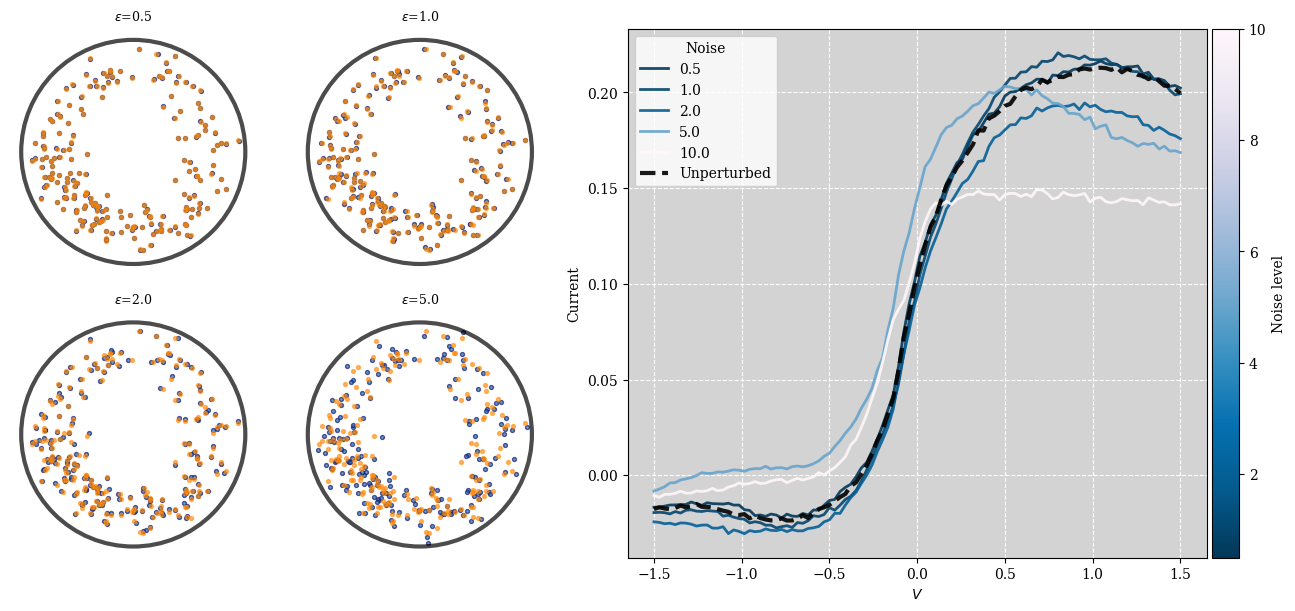

In [197]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

noise_levels = [0.5, 1.0, 2.0, 5.0, 10.0]
vs = np.linspace(-1.5, 1.5, 100)

cmap = plt.get_cmap("PuBu_r")
norm = mcolors.Normalize(vmin=min(noise_levels), vmax=max(noise_levels))

# --- Layout: main on the left, 2x2 on the right ---
fig = plt.figure(figsize=(13, 6), constrained_layout=True)
mosaic = [
    ["s1", "s2", "main"],
    ["s3", "s4", "main"],
]
axd = fig.subplot_mosaic(mosaic, gridspec_kw={"width_ratios": [1.2, 1.2, 2.5]})
ax = axd["main"]  # main axis on the left

# --- Main plot (your curves) ---
for noise in noise_levels:
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment_sigmoid/opt_sim_pert={noise}.npz")
    color = cmap(norm(noise))
    ax.plot(vs, data["current"], label=f"{noise}", c=color, lw=2.0, alpha=0.9, zorder=2)

unperturbed = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment_sigmoid/opt_sim.npz")["current"]
ax.plot(vs, unperturbed, lw=3.0, c="k", ls="--", alpha=0.9, label="Unperturbed", zorder=3)
ax.set_xlabel(r"$V$")
ax.set_ylabel("Current")
ax.grid(color="white", lw=.8, linestyle="dashed")
ax.set_facecolor("lightgray")
ax.legend(title="Noise", loc="upper left")

# Optional colorbar for the main mapping
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Noise level")

pad = 0.3
for key, noise in zip(["s1", "s2", "s3", "s4"], noise_levels):
    a = axd[key]
    pos = np.loadtxt(f"/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches_1e6_vonMises_beta/vonMises_beta_SM.txt")
    perturbed_pos = np.loadtxt(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment_sigmoid/vonMises_beta_SM_pert_ns={noise}.txt")
    a.scatter(*perturbed_pos.T, s=8, alpha=0.7, edgecolor="midnightblue")
    a.scatter(*pos.T, s=8, alpha=0.6, edgecolor="darkorange")
    a.set_title(f"$\epsilon$={noise}", fontsize=9)
    a.set_aspect("equal", adjustable="box")
    a.set_xticks([])
    a.set_yticks([])

    a.spines[["top", "bottom", "right", "left"]].set_visible(False)

    circle = ps.Circle(xy=(0.0, 0.0), radius=R, fill=None, lw=3., alpha=0.7)

    a.add_patch(circle)

plt.savefig("/home/hd/hd_hd/hd_gy283/kmc_project/data/pngs/sigmoid_perturbation.pdf")